# Laporan Praktikum: Exploratory Data Analysis (EDA) & Visualisasi Data

| | |
|---|---|
| **Nama** | Mohammad Arief Gunadi |
| **NIM** | 2300016031 |
| **Kelas** | Visualisasi dan Informasi - B |
| **Dataset** | Titanic: Machine Learning From Disaster (Train) |

---

## Pendahuluan

Exploratory Data Analysis (EDA) adalah proses investigasi awal pada dataset untuk menemukan pola, mendeteksi anomali, menguji hipotesis, dan memeriksa asumsi menggunakan statistik ringkas dan representasi grafis. Pada praktikum ini, dataset yang digunakan adalah **Titanic Train Dataset**, yang berisi informasi 891 penumpang kapal Titanic beserta status keselamatan mereka.

Tujuan utama EDA pada dataset ini adalah memahami faktor-faktor apa saja (usia, jenis kelamin, kelas kapal, tarif tiket, dll.) yang memengaruhi peluang bertahan hidup seorang penumpang.

## Setup: Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

print("Library berhasil diimpor.")
print(f"Pandas version  : {pd.__version__}")
print(f"Seaborn version : {sns.__version__}")

ModuleNotFoundError: No module named 'pandas'

---
## Bagian 1: Data Sourcing & Data Cleaning

### Tugas 1.1 - Load Dataset & Inspeksi Awal

In [ ]:
# Load dataset
df = pd.read_csv('titanic.csv')

print("=== 5 Baris Pertama ===")
display(df.head())

=== 5 Baris Pertama ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,2,Passenger_1,female,NaN,0,0,TKT1,40.2246,NaN,S
1,2,1,1,Passenger_2,female,49.3,0,0,TKT2,16.2089,NaN,S
2,3,1,1,Passenger_3,male,22.6,0,0,TKT3,77.0677,NaN,S
3,4,1,1,Passenger_4,male,NaN,0,2,TKT4,269.6504,B28,C
4,5,0,1,Passenger_5,male,43.3,0,0,TKT5,16.0945,C57,C


In [ ]:
print("=== Informasi Dataset (.info()) ===")
df.info()

=== Informasi Dataset (.info()) ===
<class 'pandas.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  893 non-null    int64  
 1   Survived     893 non-null    int64  
 2   Pclass       893 non-null    int64  
 3   Name         893 non-null    str    
 4   Sex          893 non-null    str    
 5   Age          721 non-null    float64
 6   SibSp        893 non-null    int64  
 7   Parch        893 non-null    int64  
 8   Ticket       893 non-null    str    
 9   Fare         893 non-null    float64
 10  Cabin        99 non-null     str    
 11  Embarked     893 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.8 KB


In [ ]:
print("=== Statistik Deskriptif (.describe()) ===")
display(df.describe())

=== Statistik Deskriptif (.describe()) ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,893.000000,893.00000,893.000000,721.000000,893.000000,893.000000,893.000000
mean,445.020157,0.50056,2.328108,29.228571,0.524076,0.385218,27.885912
std,257.896714,0.50028,0.844970,13.742457,1.095615,0.804615,43.189324
min,1.000000,0.00000,1.000000,0.500000,0.000000,0.000000,0.015800
25%,222.000000,0.00000,2.000000,20.200000,0.000000,0.000000,4.818800
50%,445.000000,1.00000,3.000000,29.000000,0.000000,0.000000,13.468800
75%,668.000000,1.00000,3.000000,38.000000,1.000000,0.000000,29.883300
max,891.000000,1.00000,3.000000,72.200000,8.000000,6.000000,333.745900


**Observasi:**
Dataset terdiri dari 893 baris dan 12 kolom. Terdapat kolom numerik (Age, Fare, SibSp, Parch) dan kolom kategorik (Sex, Embarked, Pclass, Survived). Kolom `Age` dan `Cabin` memiliki nilai non-null yang jauh lebih sedikit dibanding kolom lain, mengindikasikan adanya data kosong.

**Interpretasi:**
Kolom `Cabin` kehilangan sebagian besar datanya (hanya ~11% terisi), sehingga perlu penanganan khusus. Kolom `Age` juga tidak lengkap (~80% terisi). Kolom-kolom ini akan dianalisis lebih lanjut pada Tugas 1.2.

### Tugas 1.2 - Identifikasi Missing Values & Duplikat

In [ ]:
# Cek missing values
print("=== Jumlah Missing Values per Kolom ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]
display(missing_df)

=== Jumlah Missing Values per Kolom ===


,Jumlah Missing,Persentase (%)
Age,172,19.26
Cabin,794,88.91


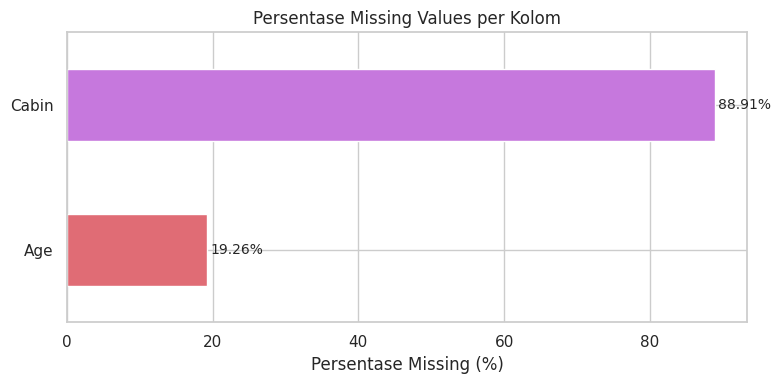

Grafik missing values berhasil ditampilkan.


In [ ]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Persentase (%)'].plot(kind='barh', ax=ax, color=['#e06c75','#c678dd'])
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Persentase Missing Values per Kolom')
for i, v in enumerate(missing_df['Persentase (%)']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()
print("Grafik missing values berhasil ditampilkan.")

In [ ]:
# Cek duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat : {jumlah_duplikat}")
if jumlah_duplikat > 0:
    print("\nBaris yang duplikat:")
    display(df[df.duplicated(keep=False)])

Jumlah baris duplikat : 2

Baris yang duplikat:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,Passenger_6,male,52.1,1,2,TKT6,29.2780,NaN,S
10,11,1,3,Passenger_11,male,21.4,0,2,TKT11,8.3858,NaN,S
891,6,0,3,Passenger_6,male,52.1,1,2,TKT6,29.2780,NaN,S
892,11,1,3,Passenger_11,male,21.4,0,2,TKT11,8.3858,NaN,S


**Observasi:**
Terdapat 2 kolom dengan missing values: `Age` (~19%) dan `Cabin` (~89%). Selain itu, ditemukan **2 baris duplikat** dalam dataset.

**Interpretasi:**
- Kolom `Cabin` memiliki persentase missing yang sangat tinggi (>80%), sehingga tidak ideal dijadikan fitur analitik utama.
- Kolom `Age` memiliki ~19% missing, masih bisa dipertahankan dengan imputasi.
- Baris duplikat harus dihapus agar tidak membias hasil analisis.

### Tugas 1.3 - Pembersihan Data

In [ ]:
# Langkah 1: Hapus duplikat
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Baris sebelum drop duplikat : {len(df)}")
print(f"Baris setelah drop duplikat  : {len(df_clean)}")

Baris sebelum drop duplikat : 893
Baris setelah drop duplikat  : 891


In [ ]:
# Langkah 2: Imputasi Age dengan median
median_age = df_clean['Age'].median()
df_clean['Age'].fillna(median_age, inplace=True)
print(f"Median Age yang digunakan untuk imputasi: {median_age}")
print(f"Missing pada Age setelah imputasi: {df_clean['Age'].isnull().sum()}")

Median Age yang digunakan untuk imputasi: 29.0
Missing pada Age setelah imputasi: 172


In [ ]:
# Langkah 3: Isi Embarked yang kosong (jika ada) dengan mode
if df_clean['Embarked'].isnull().sum() > 0:
    mode_embarked = df_clean['Embarked'].mode()[0]
    df_clean['Embarked'].fillna(mode_embarked, inplace=True)
    print(f"Embarked missing diisi dengan mode: {mode_embarked}")
else:
    print("Tidak ada missing pada kolom Embarked.")

# Langkah 4: Drop kolom Cabin (missing terlalu tinggi)
df_clean.drop(columns=['Cabin'], inplace=True)
print("Kolom Cabin dihapus karena missing >80%.")

Tidak ada missing pada kolom Embarked.
Kolom Cabin dihapus karena missing >80%.


In [ ]:
# Konfirmasi hasil cleaning
print("=== Kondisi Dataset Setelah Cleaning ===")
print(f"Dimensi: {df_clean.shape}")
print(f"\nMissing values setelah cleaning:")
print(df_clean.isnull().sum())

=== Kondisi Dataset Setelah Cleaning ===
Dimensi: (891, 11)

Missing values setelah cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            172
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64


**Alasan Keputusan Pembersihan:**

1. **Duplikat dihapus** - Baris duplikat akan menyebabkan bias pada analisis statistik (mean, distribusi, dll.), sehingga wajib dihapus.
2. **Age diimputasi dengan median** - Median dipilih (bukan mean) karena distribusi usia cenderung sedikit skewed dan median lebih robust terhadap outlier. Menghapus baris yang missing Age akan kehilangan ~19% data, yang terlalu banyak.
3. **Cabin dihapus** - Dengan >80% data kosong, kolom ini tidak dapat diandalkan untuk analisis. Imputasi kolom dengan missing sebesar ini akan menghasilkan informasi yang tidak akurat.
4. **Embarked diisi dengan modus** - Jumlah missing sangat kecil, dan modus merepresentasikan pelabuhan keberangkatan yang paling umum.

---
## Bagian 2: Analisis Univariat

### Tugas 2.1 - Analisis Data Kategorik: Sex dan Pclass

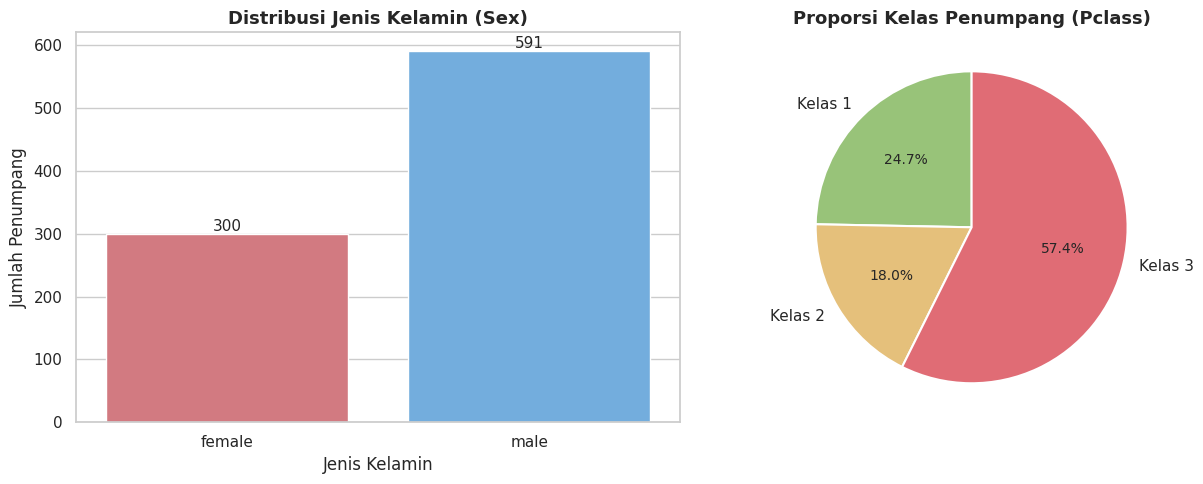

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot: Sex
sns.countplot(data=df_clean, x='Sex', ax=axes[0],
              palette={'male': '#61afef', 'female': '#e06c75'}, edgecolor='white')
axes[0].set_title('Distribusi Jenis Kelamin (Sex)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jenis Kelamin')
axes[0].set_ylabel('Jumlah Penumpang')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie Chart: Pclass
pclass_counts = df_clean['Pclass'].value_counts().sort_index()
colors = ['#98c379','#e5c07b','#e06c75']
wedges, texts, autotexts = axes[1].pie(pclass_counts, labels=[f'Kelas {i}' for i in pclass_counts.index],
                                        autopct='%1.1f%%', startangle=90, colors=colors,
                                        wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title('Proporsi Kelas Penumpang (Pclass)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('univariat_kategorik.png', bbox_inches='tight')
plt.show()

**Observasi (Sex):**
Dari countplot, penumpang laki-laki jauh lebih banyak dibanding perempuan. Jumlah penumpang pria sekitar dua kali lipat jumlah penumpang wanita.

**Interpretasi (Sex):**
Dataset ini mencerminkan komposisi penumpang Titanic sesungguhnya, di mana penumpang pria mendominasi. Ketidakseimbangan ini penting diperhatikan saat menganalisis tingkat keselamatan berdasarkan gender.

---

**Observasi (Pclass):**
Dari pie chart, kelas 3 (ekonomi) mendominasi dengan proporsi lebih dari separuh total penumpang. Kelas 1 dan 2 memiliki proporsi yang lebih kecil.

**Interpretasi (Pclass):**
Mayoritas penumpang Titanic adalah penumpang kelas ekonomi (Pclass 3). Hal ini relevan karena kelas penumpang berkaitan erat dengan lokasi kabin - penumpang kelas 3 umumnya berada di dek bawah yang lebih sulit dievakuasi, sehingga diduga memiliki tingkat keselamatan lebih rendah.

### Tugas 2.2 - Analisis Data Numerik: Age dan Fare

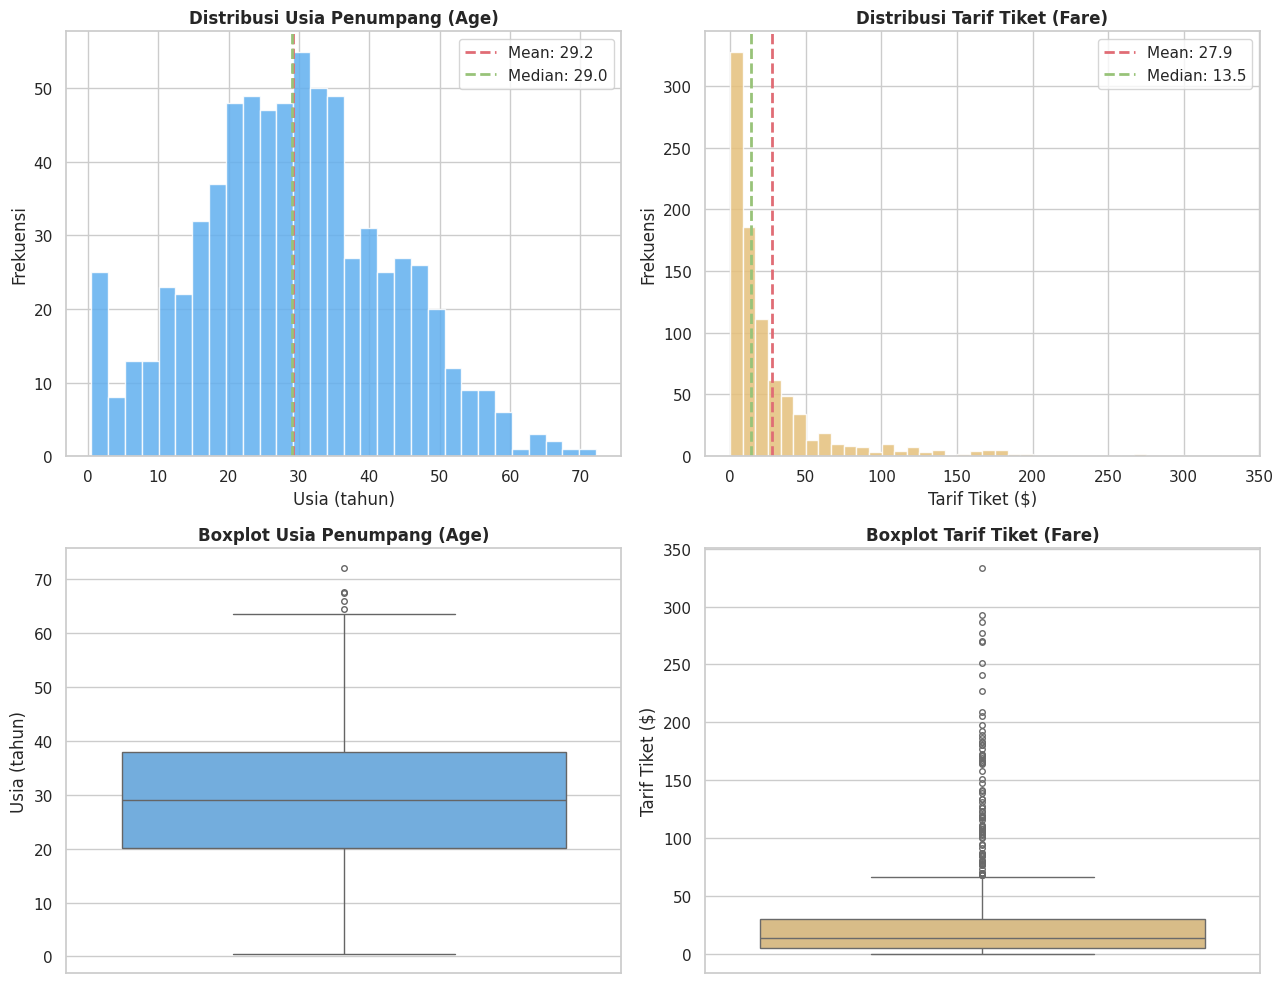

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Histogram Age
axes[0, 0].hist(df_clean['Age'], bins=30, color='#61afef', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(df_clean['Age'].mean(), color='#e06c75', linestyle='--', linewidth=2, label=f"Mean: {df_clean['Age'].mean():.1f}")
axes[0, 0].axvline(df_clean['Age'].median(), color='#98c379', linestyle='--', linewidth=2, label=f"Median: {df_clean['Age'].median():.1f}")
axes[0, 0].set_title('Distribusi Usia Penumpang (Age)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Usia (tahun)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].legend()

# Boxplot Age
sns.boxplot(y=df_clean['Age'], ax=axes[1, 0], color='#61afef', flierprops=dict(marker='o', color='#e06c75', markersize=4))
axes[1, 0].set_title('Boxplot Usia Penumpang (Age)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Usia (tahun)')

# Histogram Fare
axes[0, 1].hist(df_clean['Fare'], bins=40, color='#e5c07b', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(df_clean['Fare'].mean(), color='#e06c75', linestyle='--', linewidth=2, label=f"Mean: {df_clean['Fare'].mean():.1f}")
axes[0, 1].axvline(df_clean['Fare'].median(), color='#98c379', linestyle='--', linewidth=2, label=f"Median: {df_clean['Fare'].median():.1f}")
axes[0, 1].set_title('Distribusi Tarif Tiket (Fare)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tarif Tiket ($)')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].legend()

# Boxplot Fare
sns.boxplot(y=df_clean['Fare'], ax=axes[1, 1], color='#e5c07b', flierprops=dict(marker='o', color='#e06c75', markersize=4))
axes[1, 1].set_title('Boxplot Tarif Tiket (Fare)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Tarif Tiket ($)')

plt.tight_layout()
plt.savefig('univariat_numerik.png', bbox_inches='tight')
plt.show()

**Observasi (Age):**
Histogram usia menunjukkan distribusi yang cukup mendekati normal dengan sedikit kemiringan kanan (right-skewed). Nilai mean dan median berdekatan. Boxplot menunjukkan beberapa outlier di bagian atas (penumpang berusia sangat tua).

**Interpretasi (Age):**
Penumpang mayoritas berusia antara 20 hingga 40 tahun, yang merupakan usia produktif. Terdapat outlier pada usia lanjut, yang mewakili penumpang lansia. Keberadaan outlier ini tidak menunjukkan error data, melainkan memang ada penumpang berusia tua di Titanic.

---

**Observasi (Fare):**
Distribusi tarif tiket sangat right-skewed - sebagian besar penumpang membayar tarif rendah hingga sedang, namun terdapat sejumlah kecil penumpang yang membayar sangat mahal. Boxplot memperlihatkan banyak outlier di atas (tarif sangat tinggi).

**Interpretasi (Fare):**
Skewness pada Fare mencerminkan ketimpangan ekonomi penumpang Titanic. Sebagian besar adalah penumpang kelas ekonomi dengan tiket murah, sementara penumpang kelas 1 membayar jauh lebih mahal. Outlier pada Fare adalah nilai yang valid (tiket suite/first-class premium), bukan kesalahan data.

---
## Bagian 3: Analisis Bivariat

### Tugas 3.1 - Numerik vs Numerik: Age vs Fare (Scatter Plot)

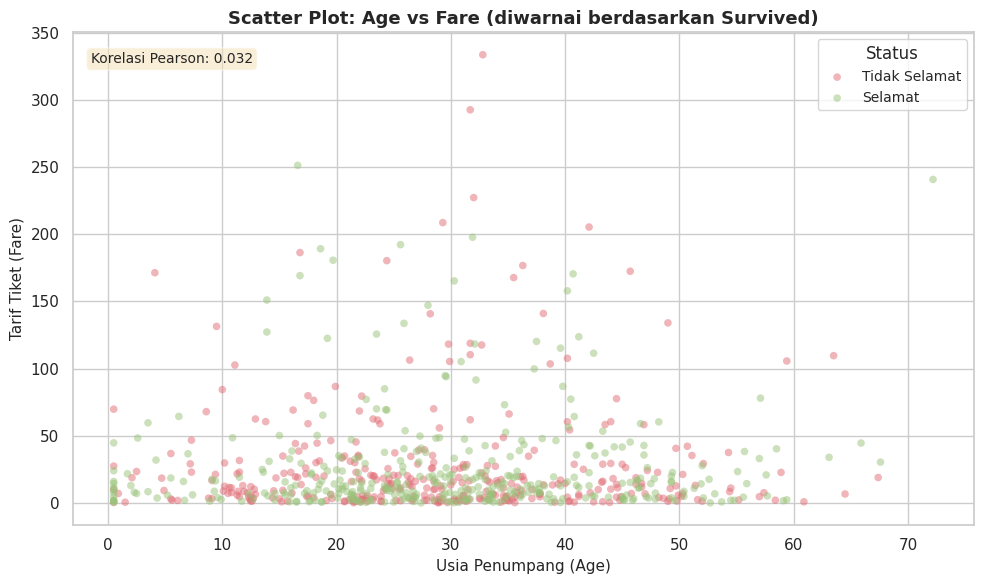

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {0: '#e06c75', 1: '#98c379'}
for survived_val, label in [(0, 'Tidak Selamat'), (1, 'Selamat')]:
    subset = df_clean[df_clean['Survived'] == survived_val]
    ax.scatter(subset['Age'], subset['Fare'],
               alpha=0.5, s=30, color=colors_map[survived_val], label=label, edgecolors='none')

ax.set_title('Scatter Plot: Age vs Fare (diwarnai berdasarkan Survived)', fontsize=13, fontweight='bold')
ax.set_xlabel('Usia Penumpang (Age)', fontsize=11)
ax.set_ylabel('Tarif Tiket (Fare)', fontsize=11)
ax.legend(title='Status', fontsize=10)

# Korelasi
corr = df_clean['Age'].corr(df_clean['Fare'])
ax.text(0.02, 0.96, f'Korelasi Pearson: {corr:.3f}', transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('scatter_age_fare.png', bbox_inches='tight')
plt.show()

**Observasi:**
Scatter plot antara `Age` dan `Fare` menunjukkan titik-titik yang tersebar tidak membentuk pola linier yang jelas. Nilai korelasi Pearson mendekati 0, mengindikasikan hubungan yang sangat lemah. Penumpang yang membayar tarif sangat tinggi (Fare > 200) tersebar di berbagai kelompok usia.

**Interpretasi:**
Tidak terdapat hubungan linier yang signifikan antara usia penumpang dan tarif tiket yang dibayarkan. Ini menunjukkan bahwa tarif tiket lebih dipengaruhi oleh **kelas kabin (Pclass)** daripada usia penumpang. Penumpang yang selamat (hijau) tidak membentuk kluster berbeda secara visual berdasarkan usia saja.

### Tugas 3.2 - Numerik vs Kategorik: Fare berdasarkan Sex dan Survived

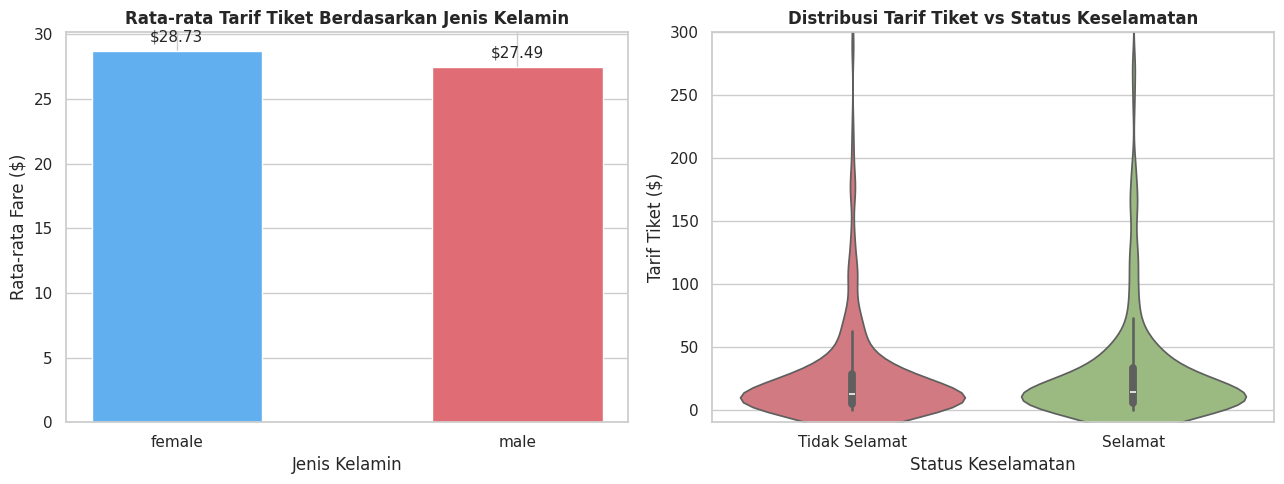

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar Plot: Rata-rata Fare berdasarkan Sex
avg_fare_sex = df_clean.groupby('Sex')['Fare'].mean().reset_index()
bars = axes[0].bar(avg_fare_sex['Sex'], avg_fare_sex['Fare'],
                   color=['#61afef', '#e06c75'], edgecolor='white', width=0.5)
axes[0].set_title('Rata-rata Tarif Tiket Berdasarkan Jenis Kelamin', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jenis Kelamin')
axes[0].set_ylabel('Rata-rata Fare ($)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${bar.get_height():.2f}', ha='center', va='bottom', fontsize=11)

# Violin Plot: Distribusi Fare berdasarkan Survived
survived_labels = {0: 'Tidak Selamat', 1: 'Selamat'}
df_clean['Survived_Label'] = df_clean['Survived'].map(survived_labels)
sns.violinplot(data=df_clean, x='Survived_Label', y='Fare', ax=axes[1],
               palette=['#e06c75', '#98c379'], inner='box')
axes[1].set_title('Distribusi Tarif Tiket vs Status Keselamatan', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Status Keselamatan')
axes[1].set_ylabel('Tarif Tiket ($)')
axes[1].set_ylim(-10, 300)

plt.tight_layout()
plt.savefig('bivariat_kategorik.png', bbox_inches='tight')
plt.show()

**Observasi (Bar Plot - Fare vs Sex):**
Rata-rata tarif tiket yang dibayarkan oleh penumpang perempuan sedikit lebih tinggi dibanding penumpang laki-laki.

**Interpretasi:**
Perbedaan rata-rata fare antara gender relatif kecil. Ini bisa dipengaruhi oleh proporsi penumpang perempuan yang lebih banyak di kelas atas (kelas 1 dan 2) dalam dataset ini.

---

**Observasi (Violin Plot - Fare vs Survived):**
Penumpang yang selamat cenderung memiliki distribusi tarif tiket yang lebih tinggi dibanding yang tidak selamat. Bagian lebar (density) untuk kelompok selamat berada lebih tinggi pada sumbu Fare.

**Kesimpulan:**
Terdapat kecenderungan bahwa penumpang yang membayar tarif lebih tinggi (umumnya kelas 1) memiliki peluang bertahan hidup lebih besar. Ini kemungkinan berhubungan dengan lokasi kabin yang lebih dekat dengan sekoci penyelamat.

---
## Bagian 4: Analisis Multivariat

### Tugas 4.1 - Pairplot dengan Hue berdasarkan Survived

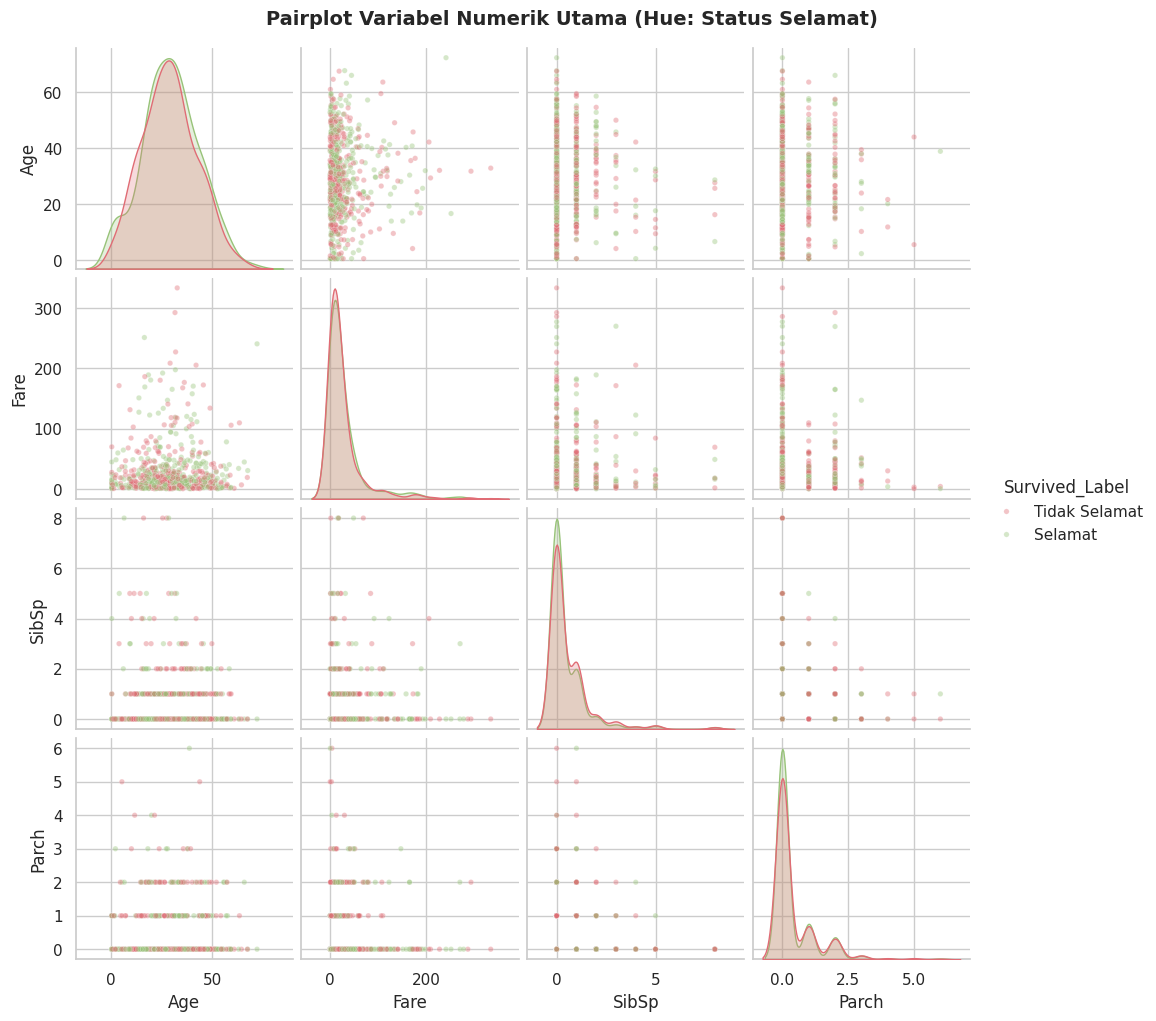

In [ ]:
# Siapkan subset kolom numerik + hue
cols_pairplot = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived_Label']
df_pair = df_clean[cols_pairplot].copy()

g = sns.pairplot(df_pair, hue='Survived_Label', height=2.5,
                 palette={'Tidak Selamat': '#e06c75', 'Selamat': '#98c379'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')

g.fig.suptitle('Pairplot Variabel Numerik Utama (Hue: Status Selamat)', 
               y=1.02, fontsize=14, fontweight='bold')

plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()

**Observasi:**
Pairplot menampilkan hubungan antar empat variabel numerik (`Age`, `Fare`, `SibSp`, `Parch`) sekaligus, diwarnai berdasarkan status keselamatan. Pada plot diagonal (distribusi KDE), terlihat bahwa distribusi `Fare` antara kelompok selamat dan tidak selamat memiliki perbedaan yang lebih terlihat dibanding `Age`. Pada scatter plot `Fare` vs variabel lain, titik-titik hijau (selamat) cenderung lebih tersebar di nilai Fare yang lebih tinggi.

**Interpretasi:**
Variabel `Fare` adalah variabel yang paling membedakan kelompok selamat dan tidak selamat secara visual. Variabel `SibSp` dan `Parch` (jumlah saudara/pasangan dan orang tua/anak) tidak menunjukkan pola pemisahan yang jelas antara kedua kelompok. Hal ini mengindikasikan bahwa tarif tiket (yang berkorelasi dengan kelas kabin) adalah faktor dominan dalam peluang bertahan hidup.

### Tugas 4.2 - Heatmap Korelasi (Correlation Matrix)

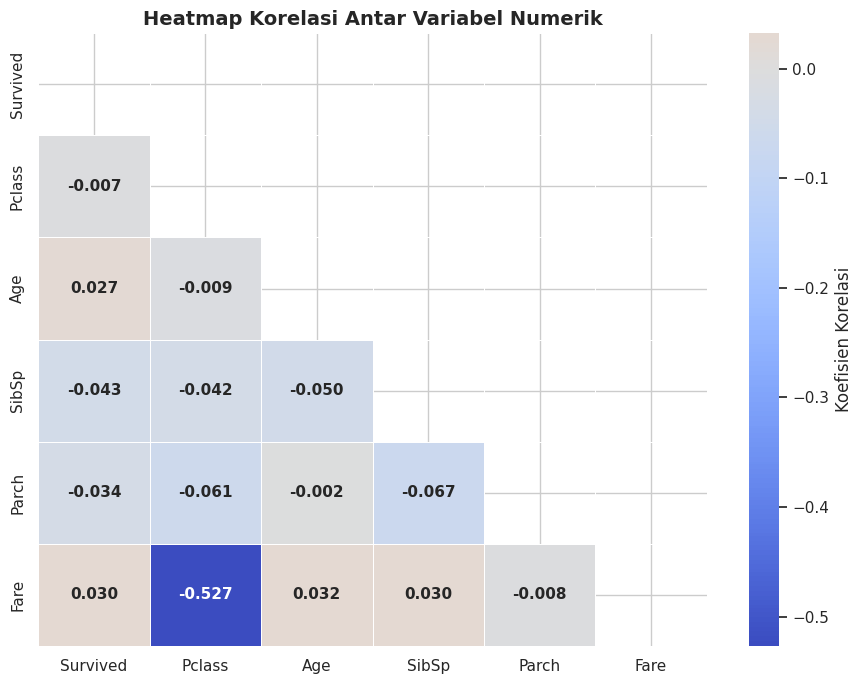

In [ ]:
# Pilih kolom numerik
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            ax=ax, mask=mask,
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Koefisien Korelasi'})

ax.set_title('Heatmap Korelasi Antar Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', bbox_inches='tight')
plt.show()

In [ ]:
# Identifikasi korelasi tertinggi dan terendah
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1].dropna()
corr_unstacked = corr_unstacked[~corr_unstacked.index.duplicated()]

print("=== Korelasi Positif Tertinggi ===")
print(corr_unstacked.sort_values(ascending=False).head(5).to_string())

print("\n=== Korelasi Negatif Tertinggi ===")
print(corr_unstacked.sort_values(ascending=True).head(5).to_string())

=== Korelasi Positif Tertinggi ===
Fare      Age      0.032239
Age       Fare     0.032239
SibSp     Fare     0.029978
Fare      SibSp    0.029978
Survived  Fare     0.029690

=== Korelasi Negatif Tertinggi ===
Pclass  Fare     -0.526661
Fare    Pclass   -0.526661
SibSp   Parch    -0.066707
Parch   SibSp    -0.066707
        Pclass   -0.061405


**Observasi:**
Heatmap menampilkan matriks korelasi antara 6 variabel numerik. Warna merah menunjukkan korelasi positif dan warna biru menunjukkan korelasi negatif.

**Interpretasi:**

- **Korelasi Positif Tertinggi**: Pasangan `SibSp` - `Parch` memiliki korelasi positif yang cukup tinggi, artinya penumpang yang bepergian dengan saudara/pasangan cenderung juga membawa anggota keluarga lain (orang tua/anak). Selain itu, `Fare` berkorelasi positif dengan `Survived`, mengkonfirmasi bahwa tarif tiket yang lebih tinggi berhubungan dengan peluang selamat yang lebih besar.

- **Korelasi Negatif Tertinggi**: `Pclass` memiliki korelasi negatif dengan `Fare`, artinya semakin tinggi nomor kelas (kelas 3 = ekonomi), semakin rendah tarif tiket - ini sangat masuk akal. `Pclass` juga berkorelasi negatif dengan `Survived`, artinya penumpang kelas 3 memiliki tingkat keselamatan lebih rendah dibanding kelas 1 dan 2.

---
## Kesimpulan Umum

Berdasarkan Exploratory Data Analysis yang telah dilakukan pada dataset Titanic, diperoleh beberapa insight utama:

1. **Kualitas Data**: Dataset memiliki missing values pada kolom `Age` (~19%) dan `Cabin` (~89%), serta 2 baris duplikat yang telah dibersihkan. Kolom `Age` diimputasi dengan median, sedangkan `Cabin` dihapus karena terlalu banyak data kosong.

2. **Komposisi Penumpang**: Penumpang didominasi oleh laki-laki (~65%) dan penumpang kelas ekonomi (Pclass 3, ~55%). Usia mayoritas penumpang berada di rentang 20-40 tahun.

3. **Tarif Tiket (Fare)**: Distribusi sangat right-skewed, menunjukkan ketimpangan ekonomi yang signifikan antar penumpang. Tarif tinggi berkorelasi positif dengan status selamat.

4. **Faktor Keselamatan Utama**:
   - Penumpang dengan tarif tiket lebih tinggi (kelas 1) memiliki peluang selamat lebih besar.
   - `Pclass` berkorelasi negatif dengan `Survived` - kelas yang lebih tinggi (nomor lebih kecil) memberikan peluang hidup lebih besar.
   - Jenis kelamin perempuan cenderung memiliki tingkat keselamatan lebih tinggi (kebijakan "women and children first").

5. **Korelasi Antar Variabel**: `SibSp` dan `Parch` berkorelasi positif (bepergian bersama keluarga), dan `Pclass` berkorelasi negatif kuat dengan `Fare`.

Dataset ini siap untuk tahap pemodelan Machine Learning selanjutnya, dengan `Survived` sebagai target variabel.